# HOMEWORK 3

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [18]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

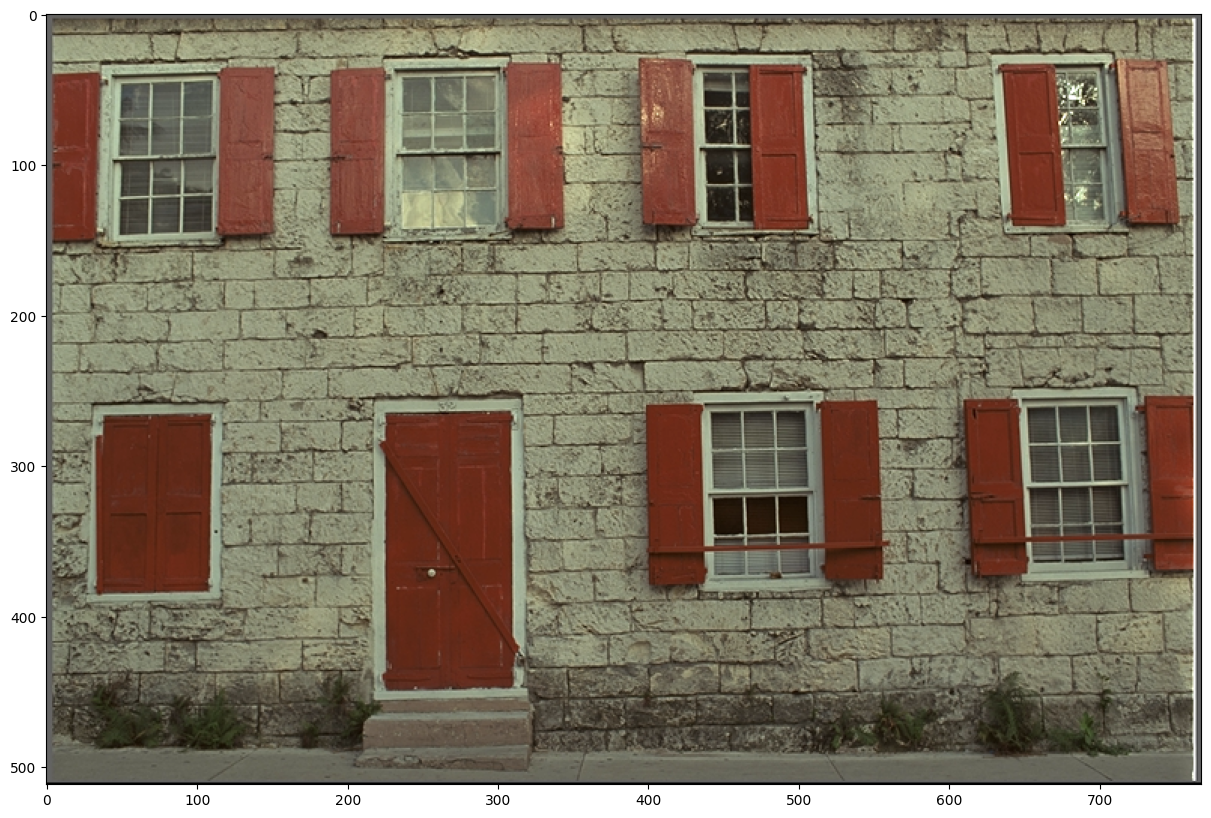

In [19]:
img = cv2.imread('../data/kodim01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

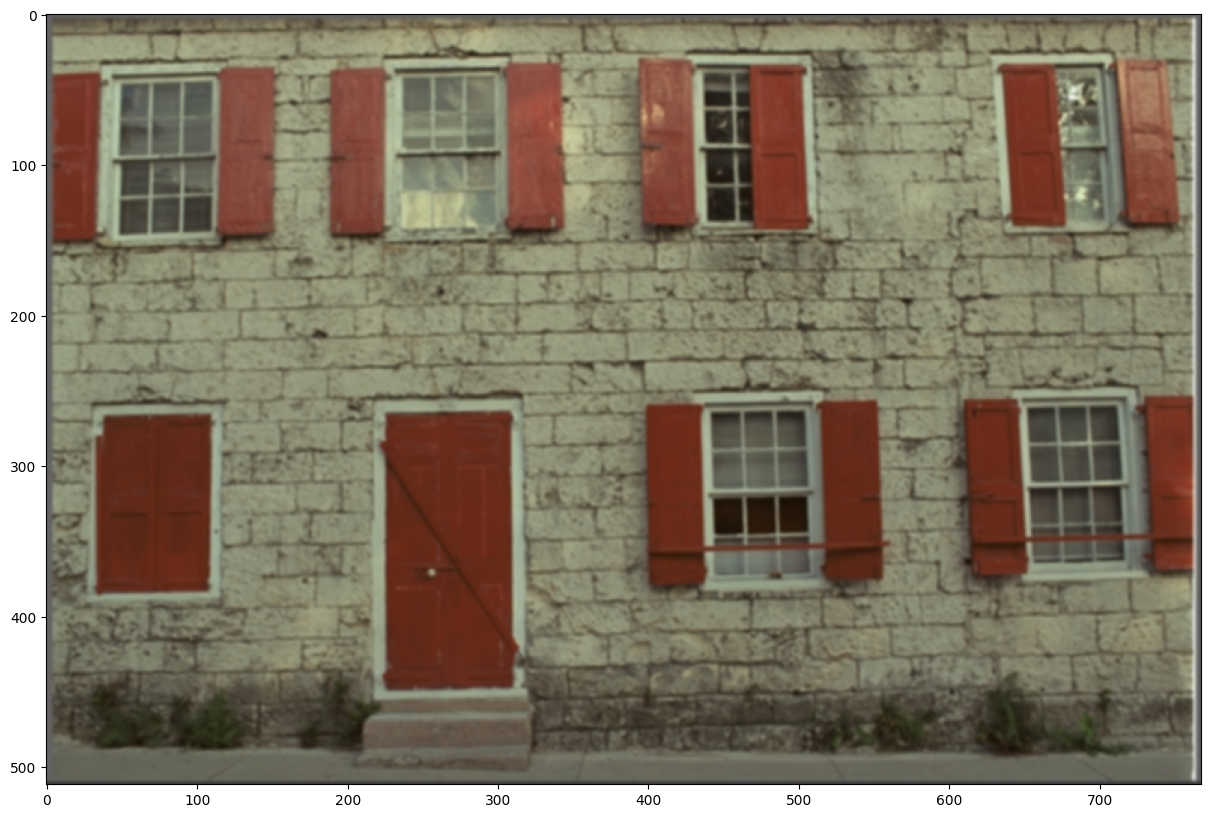

In [10]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, ksize=(5,5), sigmaX=0)
plt.imshow(unsharp)

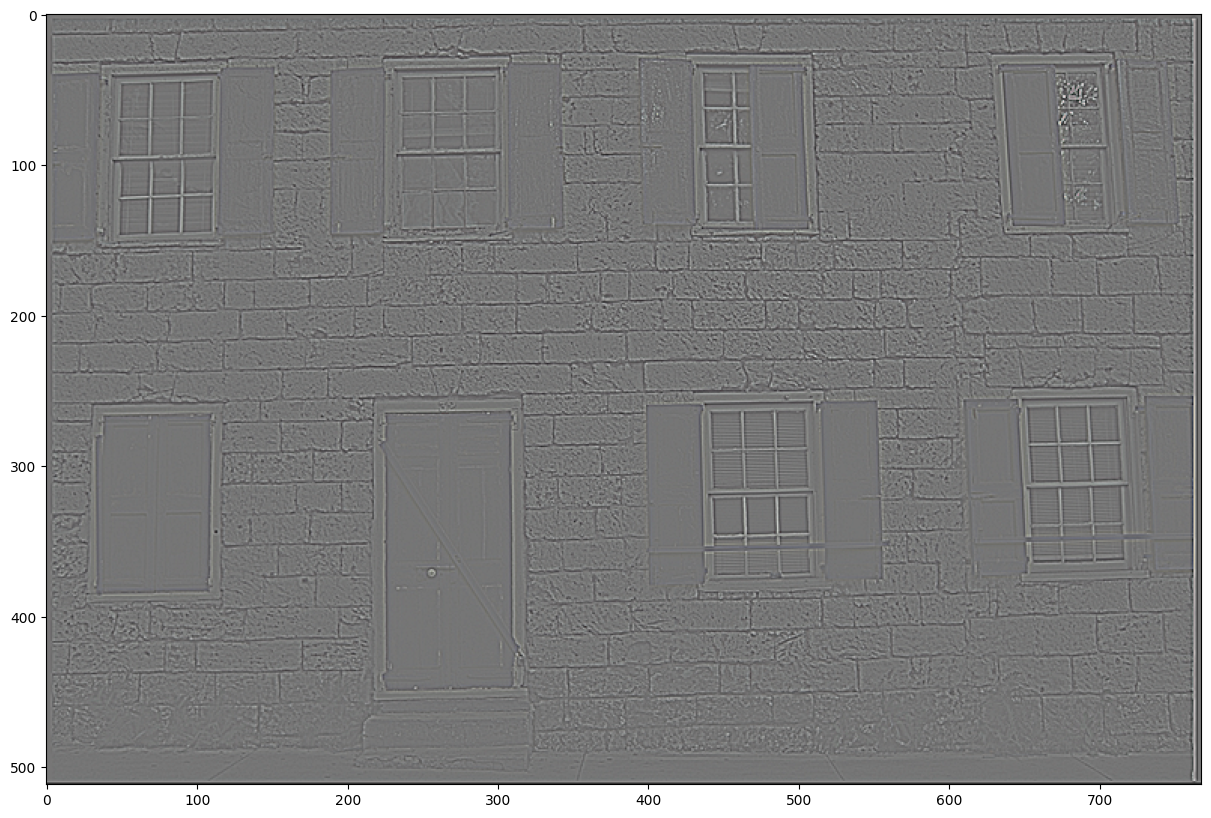

In [16]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
f_img = img.astype(np.float32) / 255.0
f_unsharp = unsharp.astype(np.float32) / 255.0

# difference (может содержать и отрицательные значения)
diff = f_img - f_unsharp

# для отображения — сдвинем в [0,1], чтобы было видно
diff_vis = (diff - diff.min()) / (diff.max() - diff.min())

img_show = cv2.cvtColor((diff_vis * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)
plt.imshow(img_show)
# plt.imshow(diff) - it is not displayed correctly because of negative values

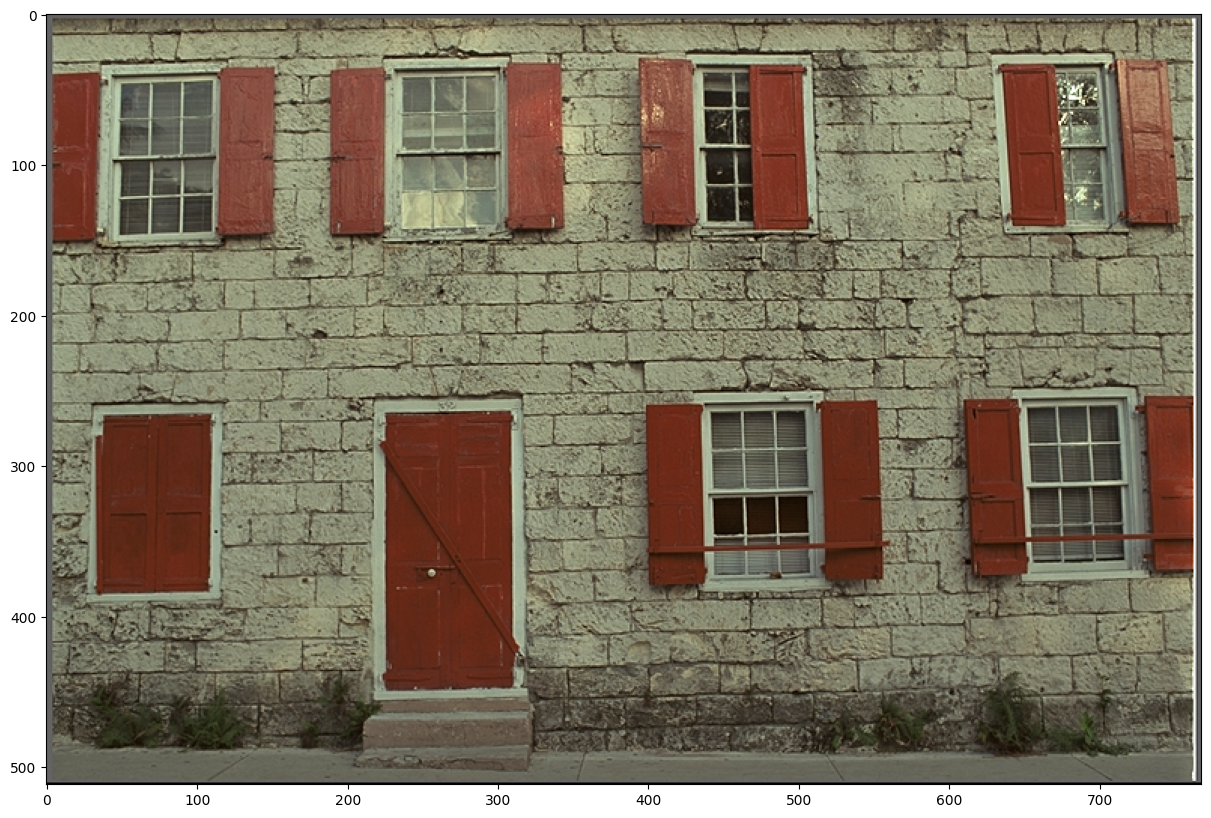

In [28]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
f_sharpened = f_img + (f_img - f_unsharp) * 0.2
sharpened = np.clip(f_sharpened * 255, 0, 255).astype(np.uint8)
plt.imshow(sharpened)

### Questions
* What is a good (reasonable) value for the `amount` parameter?
 * What happens if it is too small?
 * What happens if it is too large?

### Answers
* In practice, a reasonable range is about 0.2 to 0.5. This is strong enough to enhance details but weak enough to avoid visible artifacts. Higher values (close to 1.0 or above) often produce unnatural halos and noise.
* If the amount is too small, the sharpening effect will be barely noticeable. The image will look very similar to the original, with only a slight increase in contrast around edges.
* If the amount is too large, the image may appear overly sharp and unnatural. This can introduce artifacts such as halos around edges, increased noise, and a loss of fine details, making the image look harsh and unpleasant.